# Transfer Learning no Dataset XJTU-SY

**Projeto:** Diagnóstico de Falhas em Rolamentos Industriais via CWT + Deep Learning  
**Dataset:** Xi'an Jiaotong University (XJTU-SY — 25.6 kHz, Falhas Reais por Degradação)  
**Modelos:** ResNet-18, Inception-v3 e EfficientNet-B0 (Fine-Tuning com pesos pré-treinados no ImageNet)  
**Objetivo:** Avaliar e comparar o desempenho das arquiteturas clássicas de Transfer Learning no diagnóstico de falhas em rolamentos no dataset XJTU-SY.

---


## 1. Importação de Módulos e Configurações


In [2]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name in ['1_cwru', '2_paderborn', '3_cross_domain', '4_order_tracking', '5_xjtu'] else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

from src.config import RANDOM_SEED, XJTU_PROCESSED_DIR, NUM_EPOCHS, LEARNING_RATE
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

from src.transfer_learning import train_and_evaluate_transfer_model
from src.visualization import plot_training_curves, plot_confusion_matrix

resultados_xjtu = {}


## 2. Experimento 1: ResNet-18 (Fine-Tuning)


[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.0858 - Acc: 96.93% | Val Loss: 0.0013 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0038 - Acc: 100.00% | Val Loss: 0.0007 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0026 - Acc: 100.00% | Val Loss: 0.0005 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0021 - Acc: 100.00% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0018 - Acc: 99.95% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0018 - Acc: 99.95% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 06/10.
Época [07/10] | Treino Loss: 0.0018 - Acc: 99.95% | Val Loss: 0.0002 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na é

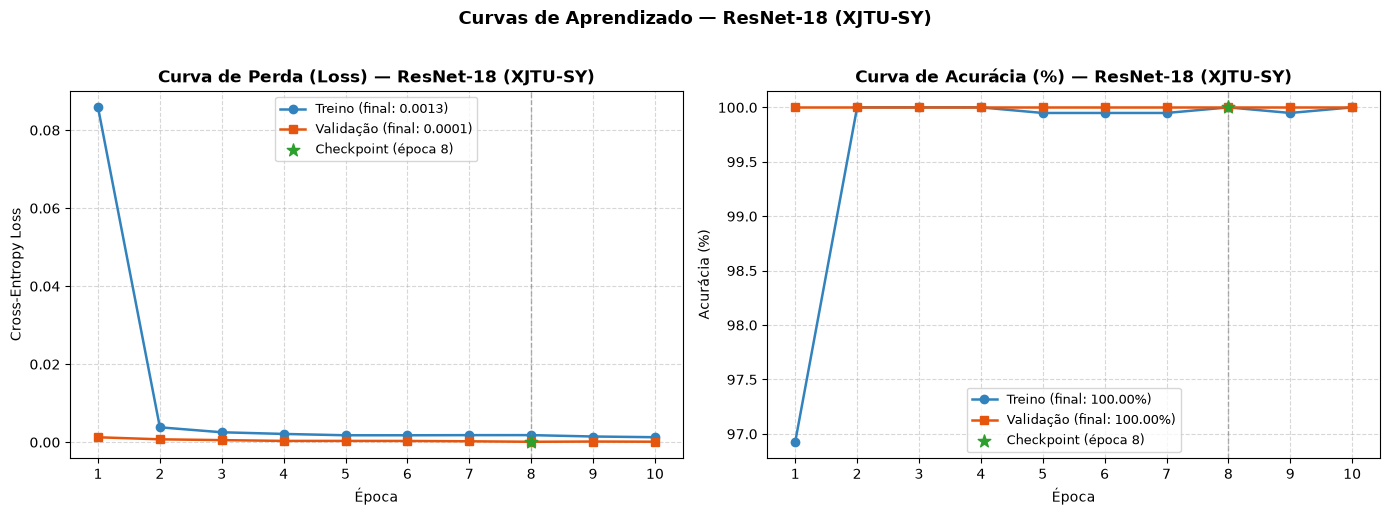

[INFO] Figura salva em: ../../docs/images/confusion_matrix_xjtu_resnet.png


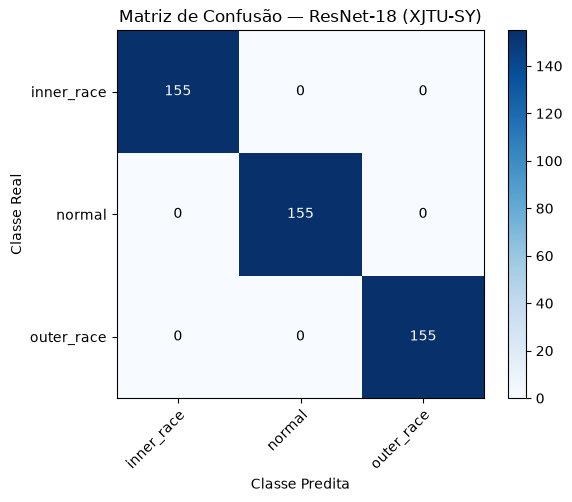

In [3]:
res_resnet18 = train_and_evaluate_transfer_model(
    model_name="resnet18",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=XJTU_PROCESSED_DIR,
    checkpoint_prefix="checkpoint_xjtu"
)
resultados_xjtu["ResNet-18"] = res_resnet18

plot_training_curves(
    res_resnet18["history"],
    model_name="ResNet-18 (XJTU-SY)",
    save_path="../../docs/images/training_curves_xjtu_resnet.png"
)

plot_confusion_matrix(
    res_resnet18,
    model_name="ResNet-18 (XJTU-SY)",
    save_path="../../docs/images/confusion_matrix_xjtu_resnet.png"
)


## 3. Experimento 2: Inception-v3 (Fine-Tuning)


[INFO] EXPERIMENTO TRANSFER LEARNING: INCEPTION_V3 | Freeze=False | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.2346 - Acc: 93.55% | Val Loss: 0.0056 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0121 - Acc: 99.90% | Val Loss: 0.0025 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0081 - Acc: 99.90% | Val Loss: 0.0023 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0050 - Acc: 100.00% | Val Loss: 0.0008 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0031 - Acc: 100.00% | Val Loss: 0.0007 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0022 - Acc: 99.95% | Val Loss: 0.0005 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 06/10.
Época [07/10] | Treino Loss: 0.0041 - Acc: 99.95% | Val Loss: 0.0006 - Acc: 100.00% 
Época [08/10] | Treino Loss: 0.0

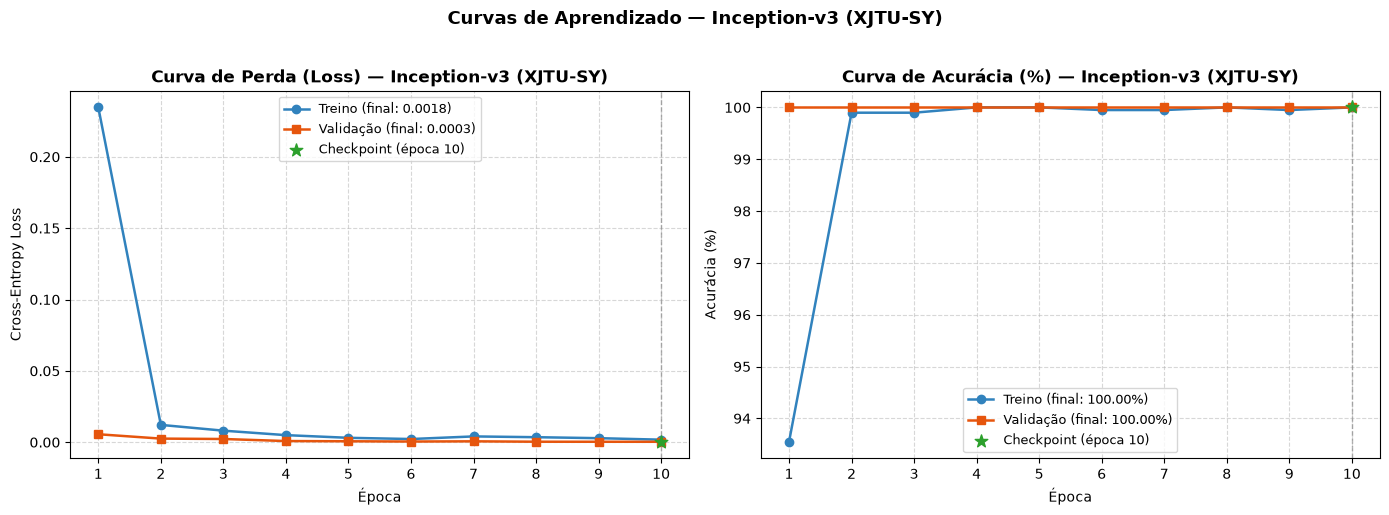

[INFO] Figura salva em: ../../docs/images/confusion_matrix_xjtu_inception.png


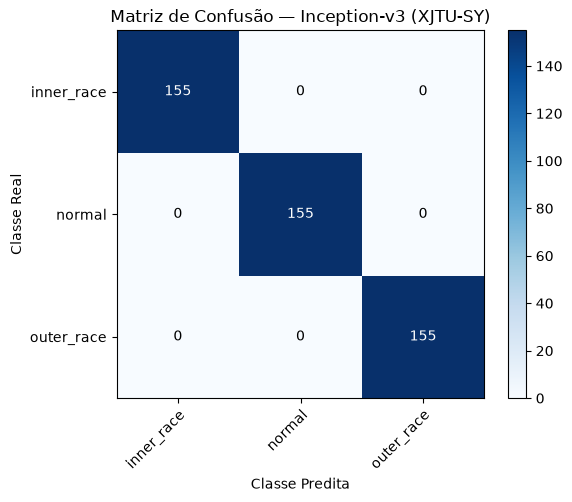

In [4]:
res_inception = train_and_evaluate_transfer_model(
    model_name="inception_v3",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=XJTU_PROCESSED_DIR,
    checkpoint_prefix="checkpoint_xjtu"
)
resultados_xjtu["Inception-v3"] = res_inception

plot_training_curves(
    res_inception["history"],
    model_name="Inception-v3 (XJTU-SY)",
    save_path="../../docs/images/training_curves_xjtu_inception.png"
)

plot_confusion_matrix(
    res_inception,
    model_name="Inception-v3 (XJTU-SY)",
    save_path="../../docs/images/confusion_matrix_xjtu_inception.png"
)


## 4. Experimento 3: EfficientNet-B0 (Fine-Tuning)


[INFO] EXPERIMENTO TRANSFER LEARNING: EFFICIENTNET_B0 | Freeze=False | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.4383 - Acc: 92.78% | Val Loss: 0.0414 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0523 - Acc: 99.85% | Val Loss: 0.0074 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0228 - Acc: 99.85% | Val Loss: 0.0030 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0140 - Acc: 99.95% | Val Loss: 0.0015 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0082 - Acc: 100.00% | Val Loss: 0.0012 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0050 - Acc: 99.95% | Val Loss: 0.0009 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 06/10.
Época [07/10] | Treino Loss: 0.0056 - Acc: 99.95% | Val Loss: 0.0008 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo

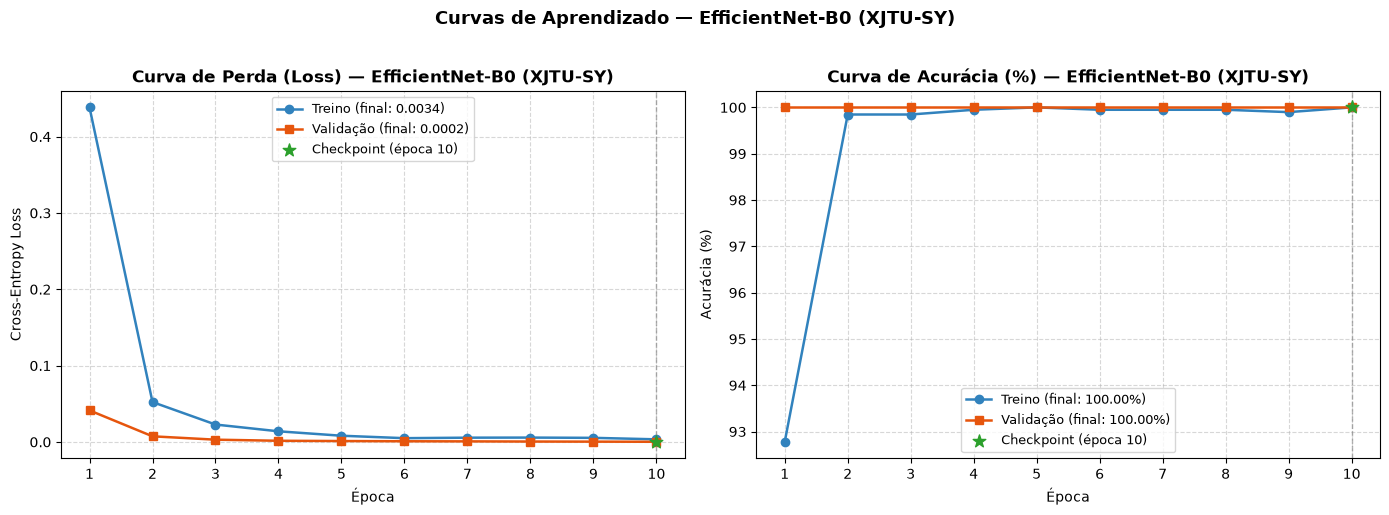

[INFO] Figura salva em: ../../docs/images/confusion_matrix_xjtu_efficientnet.png


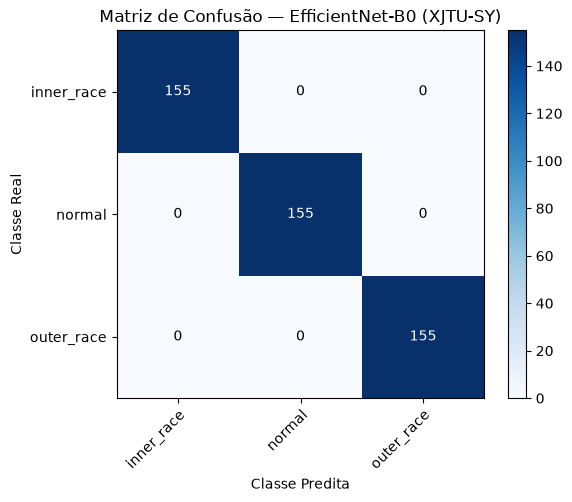

In [5]:
res_efficient = train_and_evaluate_transfer_model(
    model_name="efficientnet_b0",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=XJTU_PROCESSED_DIR,
    checkpoint_prefix="checkpoint_xjtu"
)
resultados_xjtu["EfficientNet-B0"] = res_efficient

plot_training_curves(
    res_efficient["history"],
    model_name="EfficientNet-B0 (XJTU-SY)",
    save_path="../../docs/images/training_curves_xjtu_efficientnet.png"
)

plot_confusion_matrix(
    res_efficient,
    model_name="EfficientNet-B0 (XJTU-SY)",
    save_path="../../docs/images/confusion_matrix_xjtu_efficientnet.png"
)


## 5. Comparativo Consolidado de Modelos Pré-treinados no XJTU-SY


In [6]:
print("=" * 65)
print(" COMPARATIVO FINAL DE DESEMPENHO NO DATASET XJTU-SY ")
print("=" * 65)
print(f"{'Modelo':<20} | {'Acurácia no Teste':<18} | {'Melhor Val Loss':<15}")
print("-" * 65)
for nome, res in resultados_xjtu.items():
    melhor_val_loss = min(res['history']['val_loss'])
    print(f"{nome:<20} | {res['test_acc']:6.2f}%            | {melhor_val_loss:.4f}")
print("=" * 65)


 COMPARATIVO FINAL DE DESEMPENHO NO DATASET XJTU-SY 
Modelo               | Acurácia no Teste  | Melhor Val Loss
-----------------------------------------------------------------
ResNet-18            | 100.00%            | 0.0001
Inception-v3         | 100.00%            | 0.0003
EfficientNet-B0      | 100.00%            | 0.0002
